# Ticket Closure Time Prediction

## Problem Statement
The objective of this project is to predict the estimated time and date for final closure of an opened incident ticket using attributes available at the time of ticket creation.  
This enables proactive incident management and better workload planning.


## Problem Understanding

Incident tickets go through multiple lifecycle stages before final closure.  
The time taken to close a ticket varies based on severity, category, ownership, operational complexity, and timing.

This project focuses on predicting ticket closure duration at the moment a ticket is created, ensuring the solution is realistic and deployable.


## Importing Required Libraries

In this step, the required Python libraries for data manipulation, visualization are imported.


In [2]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## Data Loading

The dataset contains incident-level information including ticket lifecycle details, categorization, severity, assignment, and resolution timestamps.


In [4]:
df=pd.read_csv('/content/incident_event_log.csv')

In [5]:
df

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119993,INC0029231,Resolved,True,0,0,8,True,Caller 2321,Opened by 17,13/5/2016 11:46,...,True,Do Not Notify,?,?,?,?,code 7,Resolved by 11,13/5/2016 12:15,18/5/2016 13:07
119994,INC0029231,Closed,False,0,0,9,True,Caller 2321,Opened by 17,13/5/2016 11:46,...,True,Do Not Notify,?,?,?,?,code 7,Resolved by 11,13/5/2016 12:15,18/5/2016 13:07
119995,INC0029232,Resolved,True,0,0,0,True,Caller 382,Opened by 108,13/5/2016 11:48,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 52,?,18/5/2016 12:07
119996,INC0029232,Closed,False,0,0,1,True,Caller 382,Opened by 108,13/5/2016 11:48,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 52,?,18/5/2016 12:07


## Data Overview

This step provides a high-level understanding of the dataset structure, data types, and presence of missing values.


In [6]:
df.shape

(119998, 36)

In [7]:
df.nunique()

,0
number,20769
incident_state,9
active,2
reassignment_count,28
reopen_count,9
sys_mod_count,115
made_sla,2
caller_id,4829
opened_by,157
opened_at,16349


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119998 entries, 0 to 119997
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   119998 non-null  object
 1   incident_state           119998 non-null  object
 2   active                   119998 non-null  bool  
 3   reassignment_count       119998 non-null  int64 
 4   reopen_count             119998 non-null  int64 
 5   sys_mod_count            119998 non-null  int64 
 6   made_sla                 119998 non-null  bool  
 7   caller_id                119998 non-null  object
 8   opened_by                119998 non-null  object
 9   opened_at                119998 non-null  object
 10  sys_created_by           119998 non-null  object
 11  sys_created_at           119998 non-null  object
 12  sys_updated_by           119998 non-null  object
 13  sys_updated_at           119998 non-null  object
 14  contact_type        

In [9]:
df.describe()

,reassignment_count,reopen_count,sys_mod_count
count,119998.000000,119998.000000,119998.000000
mean,1.151236,0.021025,5.199312
std,1.782823,0.196173,7.804628
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000
50%,1.000000,0.000000,3.000000
75%,2.000000,0.000000,7.000000
max,27.000000,8.000000,129.000000


##Datetime Processing & Target Creation

The opened_at and closed_at columns were converted to datetime format to enable time-based feature engineering. From opened_at, features such as month, day, weekday, and hour were extracted to capture temporal patterns at ticket creation time.

The target variable, closure_hours, was calculated as the total time difference (in hours) between ticket creation and closure, framing the problem as a regression task.


In [10]:
df['opened_at']=pd.to_datetime(df['opened_at'],dayfirst=True)
df['closed_at']=pd.to_datetime(df['closed_at'],dayfirst=True,format='mixed')
df['opened_date']=pd.to_datetime(df['opened_at']).dt.day
df['opened_month_name']=pd.to_datetime(df['opened_at']).dt.month_name()
df['opened_month_name'].value_counts()
df['opened_year']=pd.to_datetime(df['opened_at']).dt.year
df['opened_month']=pd.to_datetime(df['opened_at']).dt.month
df['opened_dayofweek']=pd.to_datetime(df['opened_at']).dt.dayofweek
df['opened_hour']=pd.to_datetime(df['opened_at']).dt.hour
df['closure_duration']=df['closed_at']-df['opened_at']
df['closure_duration']=df['closed_at']-df['opened_at']
df['closure_hours']=(df['closure_duration']).dt.total_seconds()/3600

After creating the target variable, original datetime columns were removed to prevent data leakage and ensure only features available at ticket creation were used for prediction.

In [11]:
df.drop('opened_at',axis=1,inplace=True)
df.drop('closed_at',axis=1,inplace=True)

In [12]:
df['opened_year'].value_counts()

,count
opened_year,
2016,119998


Dropping opened year as well since it is same for all


In [13]:
df.drop('opened_year',axis=1,inplace=True)

##Feature Selection

Here we have fixed our prediction point to be at the time of ticket creation, so any other features that would be generated later on must be removed to prevent data leaks.

Here we are dropping all the features that would tend to arise once the incident progress rather than those who are available while the incident is created, if we consider the features which arise later on this would lead to data leakage, also we are removing system/audi metadata(it is used to track/record the activities done on an incident and it wont be telling any incident characteristic) and also the features which act as identifiers are also removed

In [14]:
df.columns


Index(['number', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by',
       'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at',
       'contact_type', 'location', 'category', 'subcategory', 'u_symptom',
       'cmdb_ci', 'impact', 'urgency', 'priority', 'assignment_group',
       'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify',
       'problem_id', 'rfc', 'vendor', 'caused_by', 'closed_code',
       'resolved_by', 'resolved_at', 'opened_date', 'opened_month_name',
       'opened_month', 'opened_dayofweek', 'opened_hour', 'closure_duration',
       'closure_hours'],
      dtype='object')

In [15]:
drop_features=['number','sys_mod_count','made_sla','caller_id','opened_by','sys_created_by','sys_created_at','sys_updated_by','sys_updated_at','notify','problem_id','rfc','caused_by','closed_code','resolved_by','resolved_at']

In [16]:
len(drop_features)

16

In [17]:
df.drop(drop_features,axis=1,inplace=True)

In [18]:
df.drop(columns=['incident_state'], inplace=True)

Since the prediction is made at ticket creation time, incident_state provides post-resolution information and can cause data leakage. Therefore, it was excluded to maintain real-world prediction validity.

## Low Variance Feature Removal

To eliminate features with minimal predictive value, columns where a single category dominated more than 98% of observations were identified and removed.



In [19]:
def find_low_variance_cols(dataset,columns,threshold):
  low_variance_cols=[]
  for col in columns:
    distribution=dataset[col].value_counts(normalize=True).iloc[0]
    if distribution>threshold:
      low_variance_cols.append(col)


  return low_variance_cols



In [20]:
low_var_col=find_low_variance_cols(df,df.columns,0.98)

In [21]:
low_var_col

['reopen_count', 'contact_type', 'cmdb_ci', 'vendor']

The following columns were classified as low-variance:
- reopen_count  
- contact_type  
- cmdb_ci  
- vendor  



In [22]:
df.drop(low_var_col,axis=1,inplace=True)

In [23]:
low_var_col

['reopen_count', 'contact_type', 'cmdb_ci', 'vendor']

### Feature Pruning and Data Leakage Considerations

Certain features were excluded from the modeling phase after evaluating their information content and availability at prediction time.

- **cmdb_ci** and **vendor** were removed due to extreme dominance of a single category (>99% unknown values), resulting in near-zero variance and limited predictive value.

- **contact_type** was excluded as it showed high imbalance and primarily describes how a ticket was created rather than factors influencing its resolution duration.

- **reopen_count** was intentionally dropped to avoid temporal data leakage. Although this feature is available for reopened tickets, it is unknown at the time of initial ticket creation. Since the model is designed to predict closure time at the point of ticket opening, only features available at that moment were retained.

This pruning ensures the model is trained on informative, leakage-free features and remains suitable for real-world deployment.


## Handling Missing Values

Missing values are identified and handled appropriately to ensure data quality and model reliability.


In [24]:
df.isnull().sum()

,0
active,0
reassignment_count,0
location,0
category,0
subcategory,0
u_symptom,0
impact,0
urgency,0
priority,0
assignment_group,0


## Handling Duplicate Records

The dataset is checked for duplicate entries to prevent biased analysis and model training.

In [25]:
df[df.duplicated()]

,active,reassignment_count,location,category,subcategory,u_symptom,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,opened_date,opened_month_name,opened_month,opened_dayofweek,opened_hour,closure_duration,closure_hours
1,True,0,Location 143,Category 55,Subcategory 170,Symptom 72,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,29,February,2,0,1,5 days 10:44:00,130.733333
2,True,0,Location 143,Category 55,Subcategory 170,Symptom 72,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,29,February,2,0,1,5 days 10:44:00,130.733333
6,True,1,Location 165,Category 40,Subcategory 215,Symptom 471,2 - Medium,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,29,February,2,0,4,6 days 05:20:00,149.333333
7,True,1,Location 165,Category 40,Subcategory 215,Symptom 471,2 - Medium,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,29,February,2,0,4,6 days 05:20:00,149.333333
8,True,1,Location 165,Category 40,Subcategory 215,Symptom 471,2 - Medium,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,29,February,2,0,4,6 days 05:20:00,149.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119978,True,2,Location 161,Category 53,Subcategory 114,Symptom 596,3 - Low,3 - Low,4 - Low,Group 66,?,False,False,13,May,5,4,11,16 days 01:23:00,385.383333
119979,True,2,Location 161,Category 53,Subcategory 114,Symptom 596,3 - Low,3 - Low,4 - Low,Group 66,?,False,False,13,May,5,4,11,16 days 01:23:00,385.383333
119982,True,4,Location 161,Category 53,Subcategory 114,Symptom 596,3 - Low,3 - Low,4 - Low,Group 20,?,False,False,13,May,5,4,11,16 days 01:23:00,385.383333
119983,True,4,Location 161,Category 53,Subcategory 114,Symptom 596,3 - Low,3 - Low,4 - Low,Group 20,?,False,False,13,May,5,4,11,16 days 01:23:00,385.383333


In [26]:
df.duplicated().sum()

np.int64(38390)

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df.reset_index(drop=True,inplace=True)

## Assigned To (Resolver) Analysis

The distribution of tickets by `assigned_to` was analyzed to understand workload patterns.

In [29]:
df['assigned_to'].value_counts()

,count
assigned_to,
?,14397
Resolver 17,7344
Resolver 13,6010
Resolver 194,2347
Resolver 69,1621
...,...
Resolver 67,1
Resolver 131,1
Resolver 38,1


## Assigned To Distribution Analysis

The `assigned_to` feature was analyzed to understand how tickets are distributed among resolvers.

- A large number of tickets are marked as `?` (missing assignment).


In [30]:
df['assigned_to']=df['assigned_to'].replace('?','Unassigned')

The placeholder value `?` in the `assigned_to` column was replaced with `"Unassigned"` to clearly identify tickets without an assigned resolver.

This ensures better interpretability and consistency for further analysis.

In [31]:
resolver_count=df['assigned_to'].value_counts().sort_values(ascending=False).head(10)

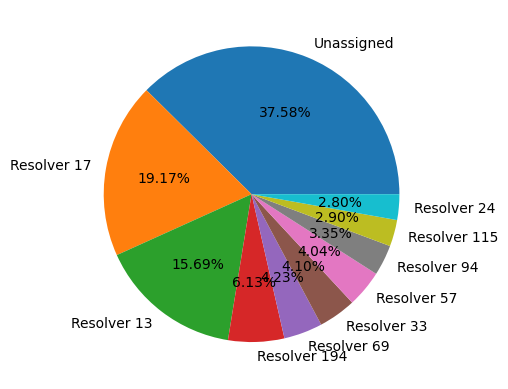

In [32]:
plt.pie(resolver_count.values,labels=resolver_count.index,autopct='%1.2f%%')
plt.show()

A pie chart was created to visualize the contribution of the top 10 resolvers.

- A significant portion of tickets remain **Unassigned**.
- A few resolvers manage a large percentage of tickets.
- The remaining resolvers contribute smaller shares individually.

This indicates a concentration of workload among specific team members.[link text](https://)

## Top 10 Resolver Dataset

A filtered dataset was created containing only the top 10 resolvers (excluding "Unassigned").

This allows focused analysis on the most active team members and helps understand their ticket handling patterns.

In [33]:
df_top_10_resolver=df[(df['assigned_to'].isin(resolver_count.index)) & (df['assigned_to']!='Unassigned')]

In [34]:
df_top_10_resolver

,active,reassignment_count,location,category,subcategory,u_symptom,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,opened_date,opened_month_name,opened_month,opened_dayofweek,opened_hour,closure_duration,closure_hours
35,True,0,Location 143,Category 9,Subcategory 110,Symptom 470,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 17,True,False,29,February,2,0,8,7 days 03:57:00,171.950000
191,True,0,Location 79,Category 9,Subcategory 164,Symptom 509,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 94,True,False,29,February,2,0,9,8 days 02:09:00,194.150000
236,True,0,Location 108,Category 20,Subcategory 125,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 17,True,False,29,February,2,0,10,5 days 01:33:00,121.550000
237,False,0,Location 108,Category 20,Subcategory 125,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 17,True,False,29,February,2,0,10,5 days 01:33:00,121.550000
250,True,0,Location 224,Category 23,Subcategory 75,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 94,True,False,29,February,2,0,10,5 days 08:24:00,128.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81586,False,0,Location 161,Category 26,Subcategory 175,Symptom 130,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 17,False,True,13,May,5,4,11,8 days 04:30:00,196.500000
81597,True,6,Location 161,Category 53,Subcategory 114,Symptom 596,3 - Low,3 - Low,4 - Low,Group 70,Resolver 17,False,True,13,May,5,4,11,16 days 01:23:00,385.383333
81598,False,6,Location 161,Category 53,Subcategory 114,Symptom 596,3 - Low,3 - Low,4 - Low,Group 70,Resolver 17,False,True,13,May,5,4,11,16 days 01:23:00,385.383333
81603,True,0,Location 111,Category 32,Subcategory 9,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 13,False,True,13,May,5,4,11,5 days 01:21:00,121.350000


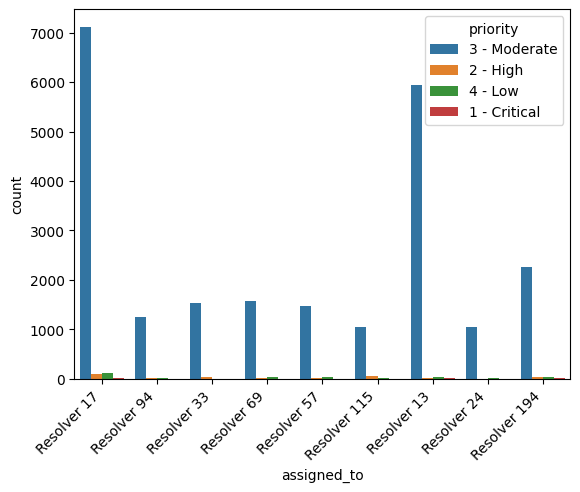

In [35]:
sns.countplot(x='assigned_to',hue='priority',data=df_top_10_resolver)
plt.xticks(rotation=45,ha='right')
plt.show()

The relationship between `assigned_to` and `priority` was analyzed for the top 10 resolvers.

- Most tickets handled by top resolvers fall under **Moderate priority**.
- High, Low, and Critical tickets represent a smaller portion.
- Workload patterns appear consistent across major resolvers.
- Some resolvers manage significantly higher ticket volumes than others.

This indicates moderate-priority incidents dominate operational workload among key team members.

## Reassignment Count Distribution

The distribution of `reassignment_count` was analyzed to understand how often tickets are reassigned.


In [36]:
reassignment_distribution=df['reassignment_count'].value_counts(normalize=True)

In [37]:
reassignment_distribution.head(5)

,proportion
reassignment_count,
0,0.506347
1,0.250625
2,0.102625
3,0.057531
4,0.033489


- Approximately half of the tickets have **no reassignment (0 transfers)**.
- Around one-quarter of tickets are reassigned once.
- Higher reassignment counts (2 or more) occur less frequently.
- The first few categories account for the majority of the data.

This suggests most tickets are resolved with minimal routing between resolvers.

In [38]:
reassignment_distribution.head(5).sum()

np.float64(0.9506175865111264)

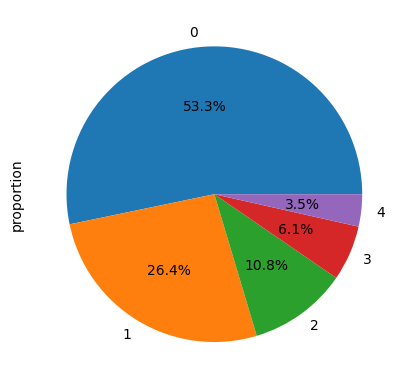

In [39]:
reassignment_distribution.head(5).plot(kind='pie',autopct='%1.1f%%')
plt.show()


A pie chart was generated to visualize the proportion of tickets based on reassignment count.

- Over 50% of tickets are resolved without reassignment.
- The likelihood of repeated transfers decreases progressively.
- Excessive reassignment is relatively rare.

This indicates generally efficient ticket handling.

## Assignment Group Cleanup


In [40]:
df['assignment_group']=df['assignment_group'].replace('?','Unknown')

The placeholder value `?` in the `assignment_group` column was replaced with `"Unknown"` for clarity.

This ensures cleaner categorical representation and better interpretability in downstream analysis.

## Distribution of Impact, Priority, and Urgency

Unique categories for `impact`, `priority`, and `urgency` were examined to understand their distribution across assignment groups.

This helps identify operational workload segmentation and severity patterns across teams.

In [41]:
impact_distibution=df['impact'].value_counts().index

In [42]:
priority_distribuition=df['priority'].value_counts().index

In [43]:
urgency_distibution=df['urgency'].value_counts().index

## Assignment Group Distribution by Priority

The top 5 assignment groups were analyzed separately for each priority level to understand workload concentration.


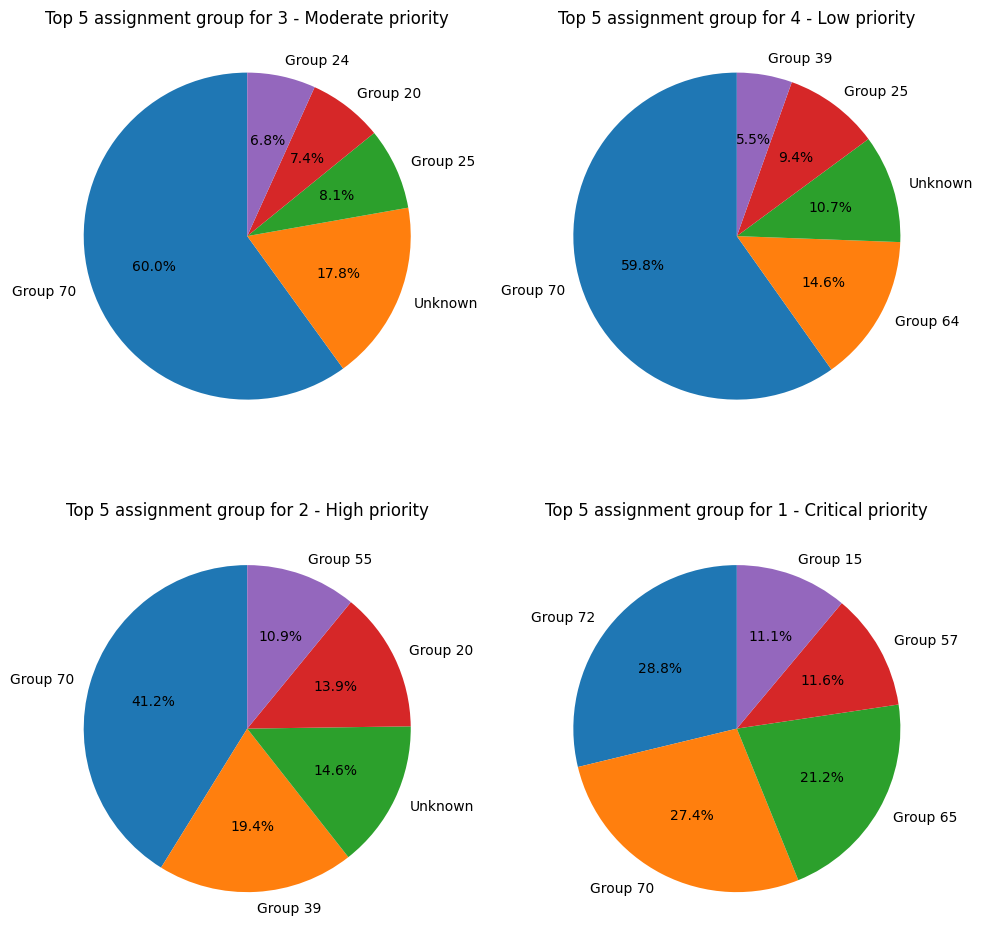

In [44]:
fig,ax=plt.subplots(2,2,figsize=(10,10))
ax=ax.flatten()
for i in range(len(priority_distribuition)):
  top5_assignment_group_based_on_priority=df[df['priority']==priority_distribuition[i]]['assignment_group'].value_counts().sort_values(ascending=False).head(5)
  ax[i].pie(top5_assignment_group_based_on_priority.values,labels=top5_assignment_group_based_on_priority.index,autopct='%1.1f%%',startangle=90)
  ax[i].set_title(f'Top 5 assignment group for {priority_distribuition[i]} priority')
plt.tight_layout()
plt.show()


### Moderate Priority
- One assignment group handles the majority of Moderate priority tickets.
- A few other groups contribute smaller shares.
- Workload appears concentrated within specific teams.

### Low Priority
- Similar to Moderate priority, one dominant group manages most tickets.
- Other groups contribute limited proportions.

### High Priority
- Ticket distribution becomes slightly more balanced.
- Multiple groups share responsibility for High priority incidents.

### Critical Priority
- Critical tickets are distributed more evenly across groups.
- No single group overwhelmingly dominates this category.




## Location Distribution by Impact Level

The top 10 locations were analyzed separately for each impact level (Medium, Low, High) to identify geographic concentration patterns.


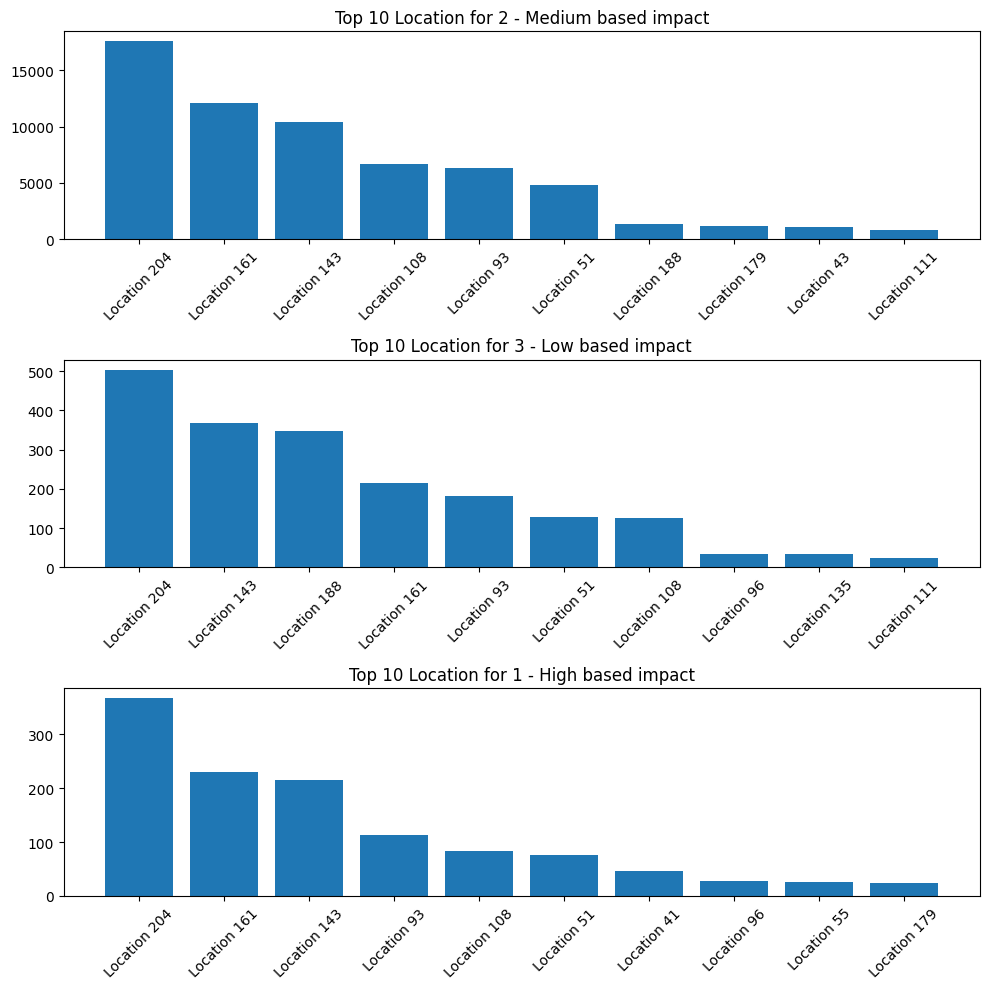

In [45]:
fix,ax=plt.subplots(3,1,figsize=(10,10))
ax=ax.flatten()
for i in range(len(impact_distibution)):
  category_based_impact=df[df['impact']==impact_distibution[i]]['location'].value_counts().sort_values(ascending=False).head(10)
  ax[i].bar(category_based_impact.index,category_based_impact.values)
  ax[i].set_title(f'Top 10 Location for {impact_distibution[i]} based impact')
  ax[i].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

### Medium Impact
- A few locations contribute a significantly higher number of medium-impact incidents.
- Ticket volume drops gradually after the top locations.
- Indicates workload concentration in specific regions.

### Low Impact
- Low-impact incidents are more moderately distributed.
- Fewer locations show very high concentrations.
- Suggests less operational strain from low-severity issues.

### High Impact
- High-impact tickets are concentrated in a limited number of locations.
- One or two locations dominate this category.
- Critical service issues may be region-specific.

Overall, geographic distribution varies depending on impact severity, highlighting location as a potentially important predictive feature.

## Category Distribution by Urgency Level

To understand which categories are most associated with different urgency levels, the top 10 categories were analyzed separately for Medium, Low, and High urgency tickets.


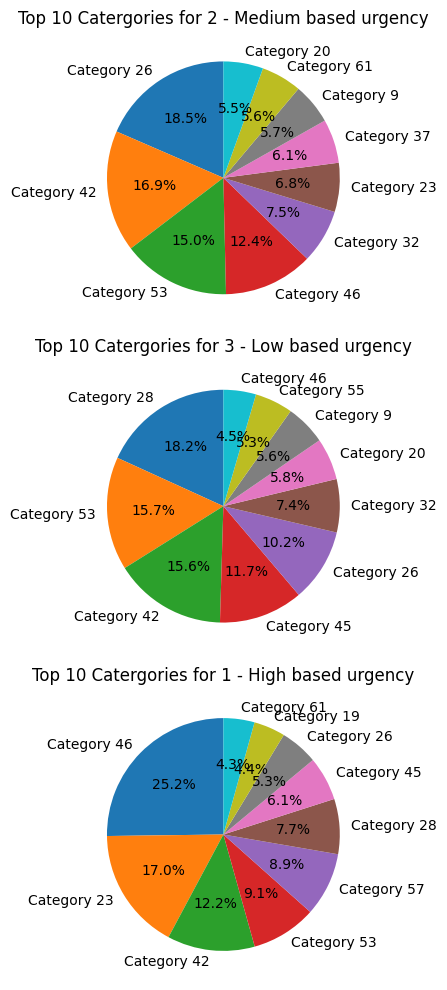

In [46]:
fix,ax=plt.subplots(3,1,figsize=(10,10))
ax=ax.flatten()
for i in range(len(urgency_distibution)):
  category_based_urgency=df[df['urgency']==urgency_distibution[i]]['category'].value_counts().sort_values(ascending=False).head(10)
  ax[i].pie(category_based_urgency.values,autopct='%1.1f%%',labels=category_based_urgency.index,startangle=90)
  ax[i].set_title(f'Top 10 Catergories for {urgency_distibution[i]} based urgency')
plt.tight_layout()
plt.show()

### Medium Urgency
- A few categories account for a large share of medium-urgency tickets.
- The remaining categories are fairly distributed.
- Indicates that routine operational issues are concentrated in specific categories.

### Low Urgency
- Category distribution is more spread out compared to High urgency.
- No single category overwhelmingly dominates.
- Suggests minor issues are diversified across services.

### High Urgency
- High-urgency tickets are concentrated within fewer key categories.
- Certain categories consistently appear across severity levels.
- Critical incidents may be strongly linked to specific service categories.

Overall, category plays an important role in determining urgency and should be considered a significant feature in predictive modeling.

## Monthly Ticket Trend Analysis

To understand seasonal patterns, ticket counts were analyzed based on the month in which they were opened.


In [47]:
month_order=['February','March','April','May']
df['opened_month_name']=pd.Categorical(df['opened_month_name'],categories=month_order,ordered=True)

/tmp/ipython-input-19991828.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('opened_month_name').size().plot(kind='line')


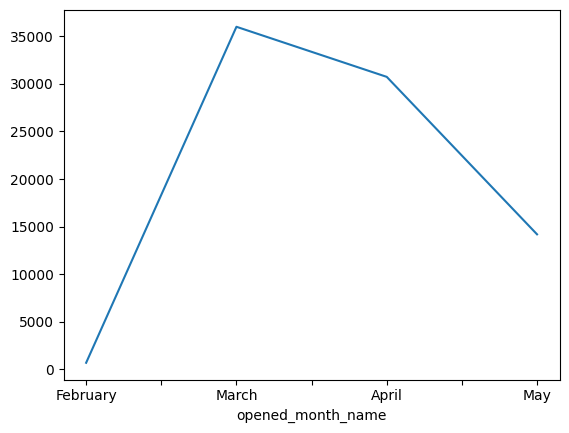

In [48]:
df.groupby('opened_month_name').size().plot(kind='line')
plt.show()

- Ticket volume increases significantly from February to March.
- March records the highest number of incidents.
- A gradual decline is observed from March to May.
- May shows comparatively lower ticket volume.

This indicates a possible seasonal or workload fluctuation pattern, which may impact resource planning and ticket closure time.

## Average Closure Duration by Assignment Group

The average closure duration was calculated for each assignment group.

In [49]:
df.groupby('assignment_group')['closure_duration'].mean().sort_values(ascending=False)

,closure_duration
assignment_group,
Group 9,119 days 07:34:06.128625472
Group 35,113 days 17:45:04.864864864
Group 63,105 days 01:37:19.285714286
Group 4,83 days 00:57:00
Group 15,77 days 13:19:45.812807882
...,...
Group 32,9 days 04:46:10
Group 19,8 days 19:07:06.713286713
Group 64,7 days 01:08:08.810526315


- Certain assignment groups show significantly higher average closure times.
- This may indicate workload imbalance, complexity differences, or resource constraints.
- Some groups resolve tickets considerably faster than others.

Assignment group performance appears to influence ticket resolution time and should be considered as an important predictive feature.

## Average Closure Duration by Urgency

The average closure duration was analyzed across different urgency levels.


In [50]:
df.groupby('urgency')['closure_duration'].mean()

,closure_duration
urgency,
1 - High,14 days 23:09:32.657054583
2 - Medium,16 days 06:56:37.274344496
3 - Low,21 days 20:47:37.571701720


- High urgency tickets are resolved relatively faster compared to others.
- Medium urgency tickets have slightly higher average resolution time.
- Low urgency tickets show the highest average closure duration.

This trend aligns with operational prioritization, where higher urgency incidents are handled more quickly.

## Average Closure Duration by Opened Month

Closure duration was analyzed based on the month in which tickets were opened.

In [51]:
df.groupby('opened_month_name')['closure_duration'].mean()


/tmp/ipython-input-280216834.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('opened_month_name')['closure_duration'].mean()


,closure_duration
opened_month_name,
February,21 days 18:15:25.777777777
March,20 days 03:42:02.957593935
April,13 days 07:45:59.039750179
May,13 days 06:51:31.793823156


- February and March show comparatively higher average resolution times.
- April and May exhibit lower average closure duration.
- This may indicate seasonal workload impact or process optimization over time.

Time-based patterns suggest that month of ticket creation can influence resolution efficiency

## Feature Type Classification

To prepare for modeling, features were categorized by data type.Understanding feature types is essential for proper encoding, scaling, and pipeline construction before model training.

In [52]:
df.select_dtypes(include='object').columns

Index(['location', 'category', 'subcategory', 'u_symptom', 'impact', 'urgency',
       'priority', 'assignment_group', 'assigned_to'],
      dtype='object')

In [53]:
df.select_dtypes(include='number').columns

Index(['reassignment_count', 'opened_date', 'opened_month', 'opened_dayofweek',
       'opened_hour', 'closure_duration', 'closure_hours'],
      dtype='object')

In [54]:
df.select_dtypes(include='bool').columns

Index(['active', 'knowledge', 'u_priority_confirmation'], dtype='object')

## Ordinal Mapping for Severity Features

To preserve the natural order of severity levels, ordinal encoding was applied to **impact**, **urgency**, and **priority**.


In [55]:
impact_order={'1 - High':3,'2 - Medium':2,'3 - Low':1}

### Impact & Urgency Mapping
The following mapping was applied to maintain hierarchical order:

- High → 3  
- Medium → 2  
- Low → 1  

This ensures that higher severity levels carry greater numerical weight in the model.


In [56]:
df['urgency']=df['urgency'].map(impact_order)
df['impact']=df['impact'].map(impact_order)

### Priority Mapping

In [57]:
df['priority']=df['priority'].str.strip()

In [58]:
priority_mapping={'3 - Moderate':2,'4 - Low':1,'2 - High':3,'1 - Critical':4}

Priority levels were mapped as:

- Critical → 4  
- High → 3  
- Moderate → 2  
- Low → 1  

By encoding these features ordinally, the model can better learn severity progression rather than treating categories independently (as in One-Hot Encoding).

In [59]:
df['priority']=df['priority'].map(priority_mapping)

## Boolean Feature Conversion

In [60]:
df[['knowledge','u_priority_confirmation','active']]=df[['knowledge','u_priority_confirmation','active']].astype(int)

Boolean features were converted into numerical format (0 and 1) for model compatibility:

- active  
- knowledge  
- u_priority_confirmation  

This allows the model to directly interpret these binary states without additional encoding.

## Dropping Redundant Features

The following columns were removed before modeling:

- `opened_month_name` – Removed after extracting numerical month features.
- `closure_duration` – Dropped after creating the target variable (`closure_duration_hours`) to prevent redundancy and data leakage.

Removing unnecessary columns ensures that only model-relevant features are retained.

In [61]:
df.drop('opened_month_name',axis=1,inplace=True)

In [62]:
df.drop('closure_duration',axis=1,inplace=True)

## Correlation Analysis

A correlation heatmap was generated to examine relationships between numerical features.

- Pearson correlation was computed for all numerical columns.
- The heatmap provides a visual overview of linear relationships.
- Highly correlated features may introduce multicollinearity, which can negatively impact certain models.

This step helps identify redundant variables and supports feature selection.

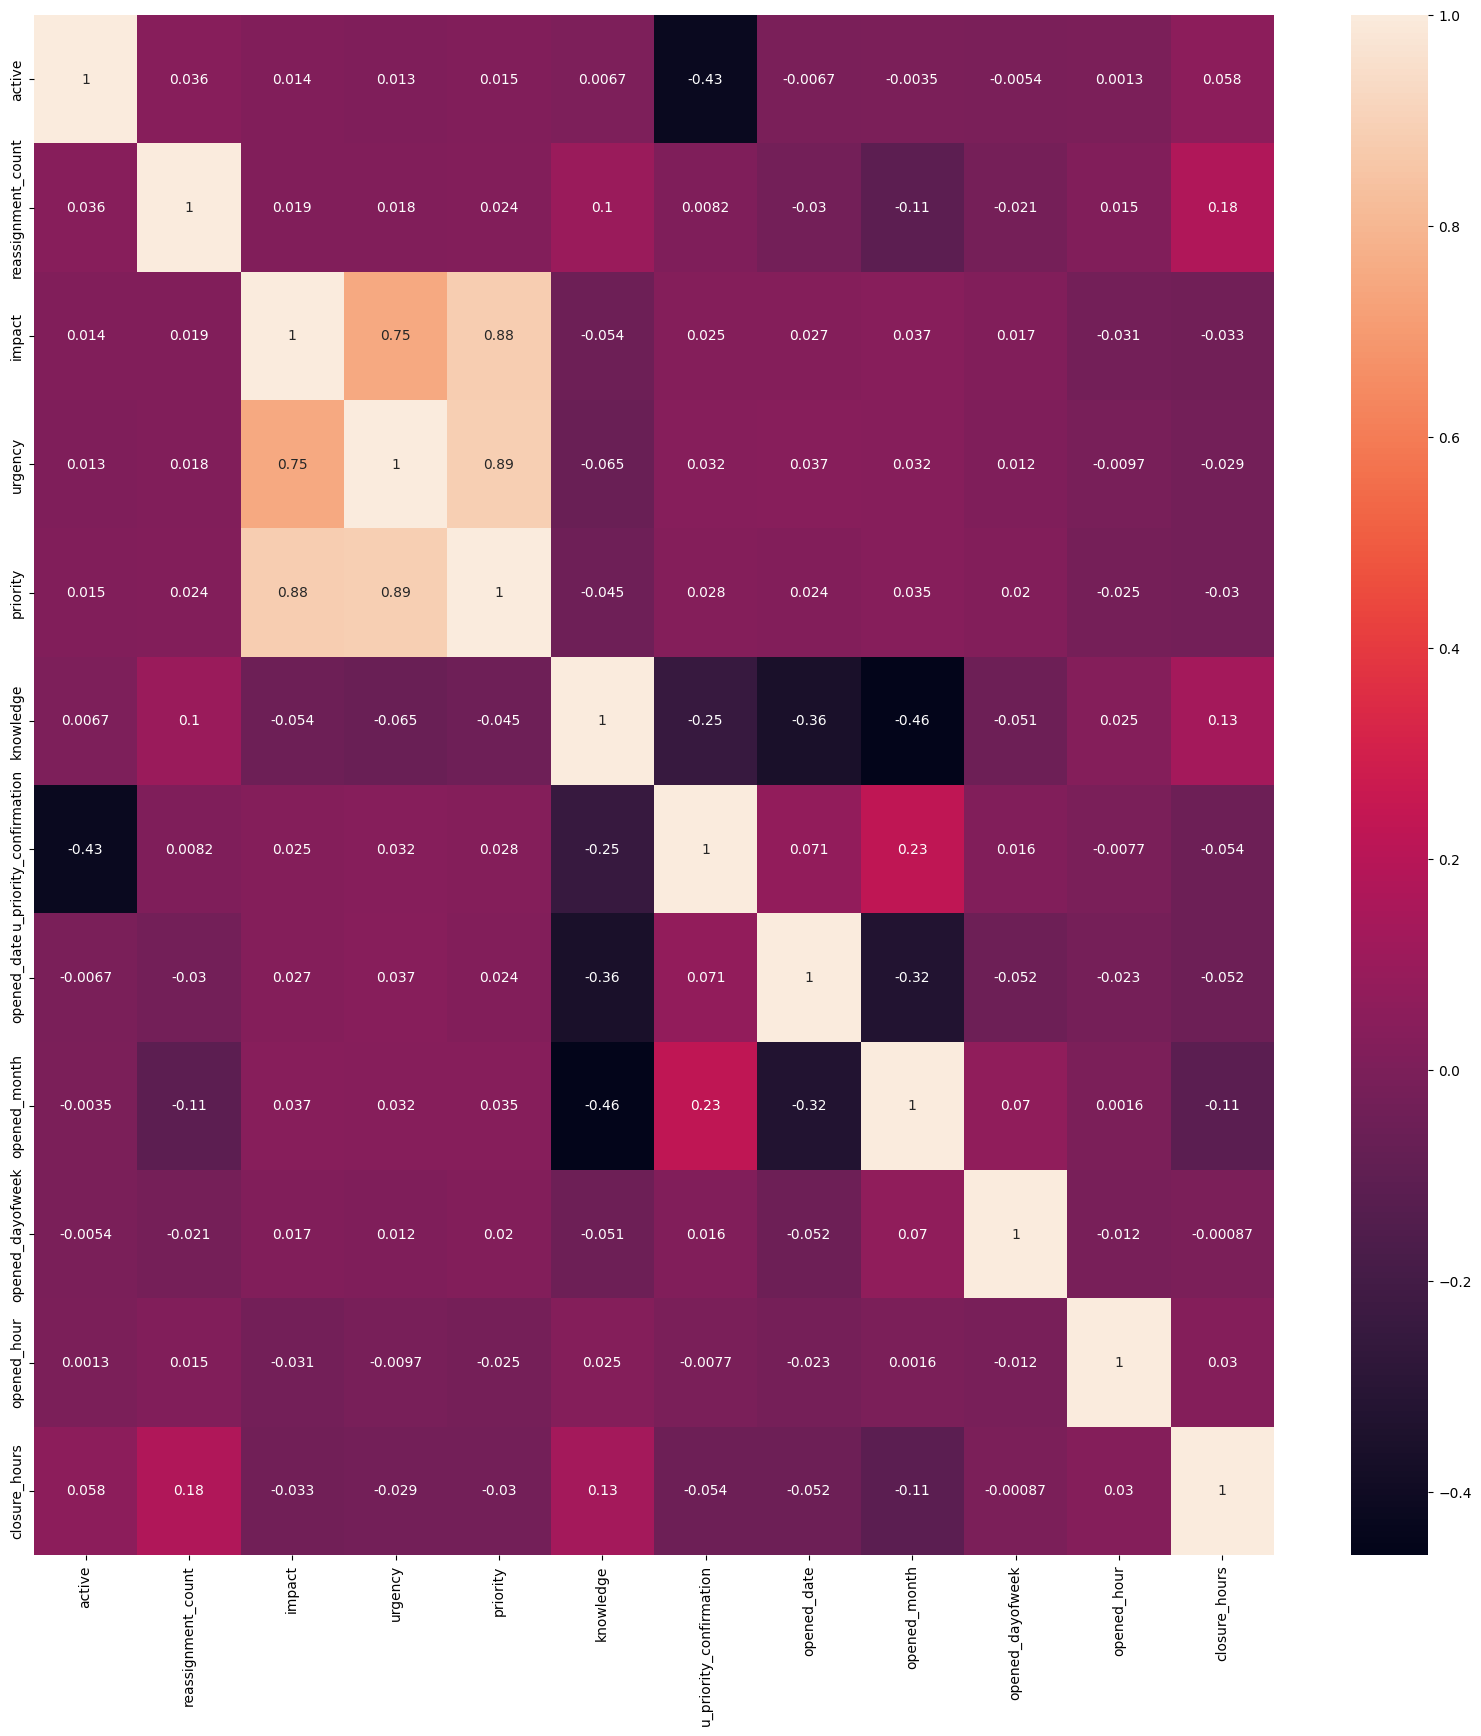

In [63]:
plt.figure(figsize=(20,20))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)
plt.show()

## High Correlation Feature Detection

A custom function was implemented to identify highly correlated features above a defined threshold (0.8).

- The function scans the correlation matrix.
- Features exceeding the threshold are flagged.
- This allows us to remove redundant predictors while preserving important information.

Reducing multicollinearity improves model stability and interpretability.

In [64]:
def correlation(dataset,threshold):
  col_name=set()
  corr_mat=dataset.corr()
  for i in range(len(corr_mat.columns)):
    for j in range(i):
      if corr_mat.iloc[i,j]>threshold:
        cor_col=corr_mat.columns[i]
        col_name.add(cor_col)
  return col_name


In [65]:
correlation(df.select_dtypes(include='number'),0.8)

{'priority'}

## Distribution Analysis of Numerical Features

Histogram plots were generated for all numerical features to examine their distribution patterns.

Analyzing feature distributions helps:
- Identify skewness and potential need for transformation.
- Understand feature spread before scaling.
- Detect anomalies or extreme values.

This completes numerical feature validation before final model training.

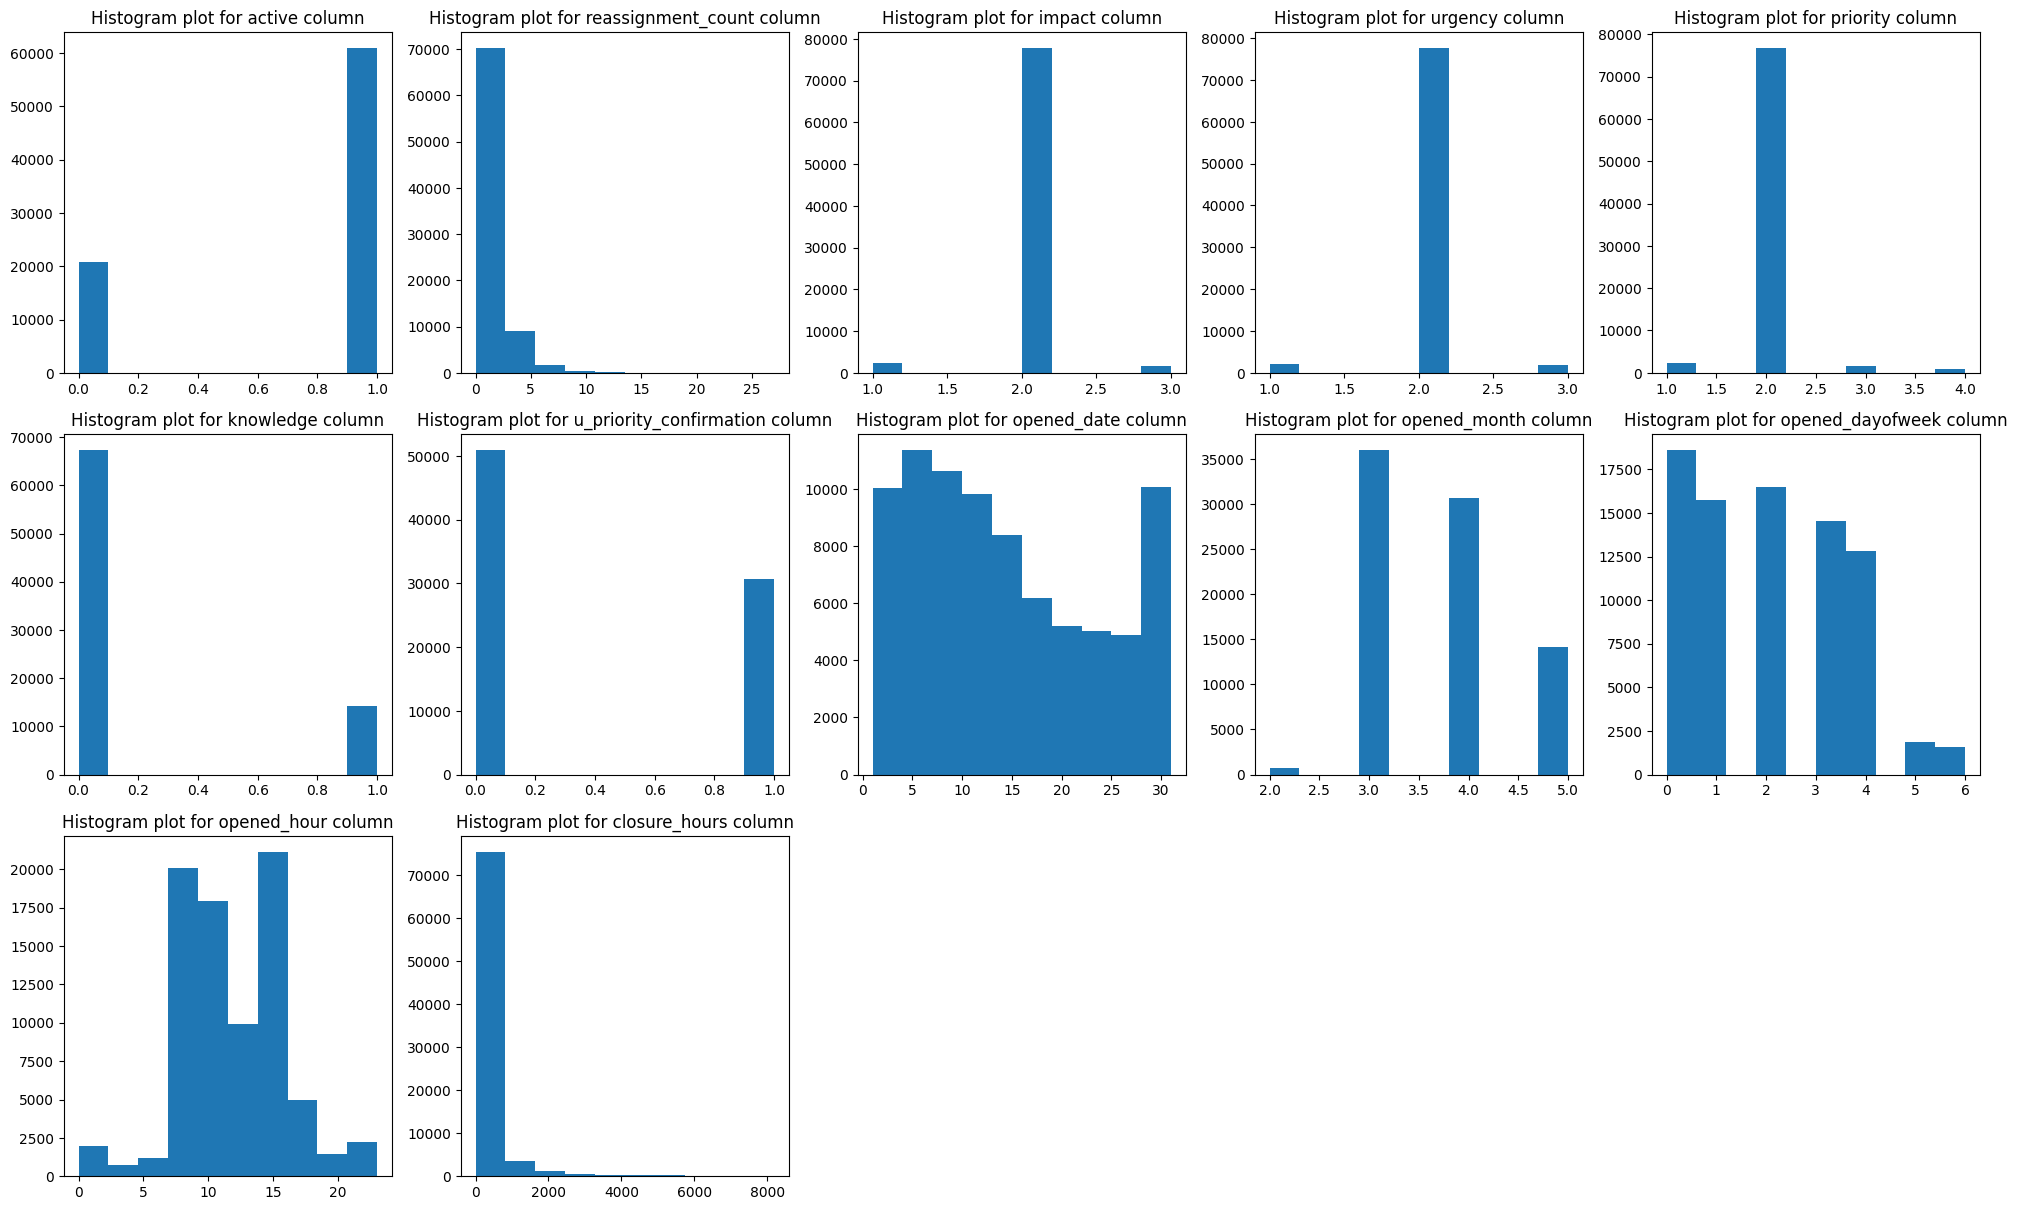

In [66]:
fig,ax=plt.subplots(5,5,figsize=(20,20))
ax=ax.flatten()
for i,col in enumerate(df.select_dtypes(include='number').columns):
  if i<len(ax):
    ax[i].hist(df[col])
    ax[i].set_title(f'Histogram plot for {col} column')
for i in range(len(df.select_dtypes(include='number').columns),len(ax)):
  fig.delaxes(ax[i])
plt.tight_layout()
plt.show()

## Categorical Feature Identification

We identified categorical variables in the dataset using data type detection.  
All features with `object` datatype were treated as categorical features.

These features require encoding before modeling, as machine learning algorithms operate on numerical representations.

In [67]:
cat_col=df.select_dtypes(include='object').columns

## Feature and Target Separation

The target variable for this problem is **`closure_hours`**, representing the time required to close a ticket.

We separated:

- **X (Features):** All input variables except `closure_hours`
- **y (Target):** `closure_hours`

This separation ensures clean modeling and prevents data leakage.

In [68]:
x=df.drop('closure_hours',axis=1)
y=df['closure_hours']

## Train–Test Split

The dataset was split into training and testing sets using an 80/20 ratio.


In [69]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)

## Data Preprocessing Strategy

To ensure robust model training and prevent data leakage, a structured preprocessing pipeline was implemented using `ColumnTransformer`.

### Numerical Features:
- Missing value imputation using **Median**
- Feature scaling using **StandardScaler**

### Categorical Features:
- Missing value imputation using **Most Frequent value**
- Encoding using **Target Encoding** with smoothing

Target encoding was selected to efficiently handle categorical variables and preserve meaningful relationships with the target variable.

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import category_encoders as ce

## Numerical Pipeline

For numerical features:

1. Missing values were imputed using the median.
2. Features were standardized to ensure consistent scale across variables.


In [71]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('Scaler',StandardScaler())
])

## Categorical Pipeline (Target Encoding)

Categorical variables were processed using:

- Most frequent value imputation
- Target Encoding with smoothing

Smoothing was applied to reduce overfitting by balancing category-level means with the global target mean.


In [72]:
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',ce.TargetEncoder(smoothing=5,handle_unknown='value',handle_missing='value'))
])

## ColumnTransformer Integration

A `ColumnTransformer` was used to:

- Apply numerical preprocessing to numerical features
- Apply categorical preprocessing to categorical features


In [73]:
num_col=x_train.select_dtypes(include='number').columns
cat_col=x_train.select_dtypes(include='object').columns
preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_col),
    ('cat',cat_pipeline,cat_col)
])


## Baseline Model – Linear Regression

A Linear Regression model was implemented as a baseline model to establish initial performance.

This provides a benchmark comparison against ensemble models and advanced approaches.

In [74]:
from sklearn.linear_model import LinearRegression

lr_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

In [75]:
lr_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['active', 'reassignment_count', 'impact', 'urgency', 'priority',
       'knowledge', 'u_priority_confirmation', 'opened_date', 'opened_month',
       'opened_dayofweek', 'opened_hour'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   TargetEncoder(smoothing=5))]),
                                                  Index(['location', 'category', 'subcategory', 'u_symptom', 'assignment_group',
       'assigned_to'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

## Random Forest Regressor

A Random Forest Regressor was implemented to capture non-linear relationships in the data.

Random Forest is an ensemble learning method that builds multiple decision trees and aggregates their predictions to improve stability and reduce variance.


In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',RandomForestRegressor(n_estimators=100,random_state=45))
])

In [77]:
rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['active', 'reassignment_count', 'impact', 'urgency', 'priority',
       'knowledge', 'u_priority_confirmation', 'opened_date', 'opened_month',
       'opened_dayofweek', 'opened_hour'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   TargetEncoder(smoothing=5))]),
                                                  Index(['location', 'category', 'subcategory', 'u_symptom', 'assignment_group',
       'assigned_to'],
      dtype='object'))])),
                ('regressor', RandomForestRegressor(random_state=45))])

## XGBoost Regressor

An XGBoost Regressor was implemented as a gradient boosting model to further improve predictive performance.

XGBoost builds trees sequentially, where each new tree attempts to correct errors from previous trees.


In [78]:
from xgboost import XGBRegressor

xgb_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',XGBRegressor(n_estimators=100,random_state=45))
])

In [79]:
xgb_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['active', 'reassignment_count', 'impact', 'urgency', 'priority',
       'knowledge', 'u_priority_confirmation', 'opened_date', 'opened_month',
       'opened_dayofweek', 'opened_hour'],
      dtype='object')),
                                                 ('c...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

## Model Evaluation Strategy

To evaluate model performance, the following regression metrics were used:

- **Mean Absolute Error (MAE)** – Measures average absolute prediction error.
- **Mean Squared Error (MSE)** – Penalizes larger errors more heavily.
- **R² Score** – Indicates proportion of variance explained by the model.


In [80]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
def evaluate_model(model,name):
  y_pred=model.predict(x_test)
  print(f'Mean Absolute Error of {name}',mean_absolute_error(y_test,y_pred))
  print(f'Mean Squared Error of {name}',mean_squared_error(y_test,y_pred))
  print(f'R2 score of {name}',r2_score(y_test,y_pred))
  print('-'*40)

## Model Performance Comparison

Multiple models were evaluated:

- Linear Regression (Baseline)
- Random Forest Regressor
- XGBoost Regressor



In [81]:
evaluate_model(lr_pipeline,'Linear Regressor Model')
evaluate_model(rf_pipeline,'Random Forest Model')
evaluate_model(xgb_pipeline,'XGB Regressor Model')


Mean Absolute Error of Linear Regressor Model 240.62834228956643
Mean Squared Error of Linear Regressor Model 256162.00780062945
R2 score of Linear Regressor Model 0.43227666786153196
----------------------------------------
Mean Absolute Error of Random Forest Model 106.60655867790439
Mean Squared Error of Random Forest Model 84220.76393472002
R2 score of Random Forest Model 0.8133443239815632
----------------------------------------
Mean Absolute Error of XGB Regressor Model 147.27530825842328
Mean Squared Error of XGB Regressor Model 106335.09016087852
R2 score of XGB Regressor Model 0.764333078789875
----------------------------------------


Random Forest demonstrated superior performance compared to the baseline model, indicating strong non-linear pattern capture.

XGBoost also performed competitively, confirming that ensemble-based methods are well-suited for this structured dataset.

## Feature Importance Analysis

To interpret the model’s decision-making process, feature importances were extracted from the trained Random Forest model.

Feature importance indicates how much each feature contributes to reducing prediction error across the decision trees.


In [82]:
feature_names=rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
important_features=rf_pipeline.named_steps['regressor'].feature_importances_

## Top 10 Influential Features

The top 10 most important features were identified and sorted in descending order based on their importance scores.

These features contribute most significantly to predicting ticket closure time.

In [83]:
top_features=pd.DataFrame({'Features':feature_names,'Importances':important_features})

In [84]:
top_10_features=top_features.sort_values(by='Importances',ascending=False).head(10)

## Feature Importance Visualization

A bar plot was generated to visualize the relative importance of the top features.

This visualization highlights the dominant factors affecting closure time and allows for easier interpretation of feature impact.

<Axes: xlabel='Importances', ylabel='Features'>

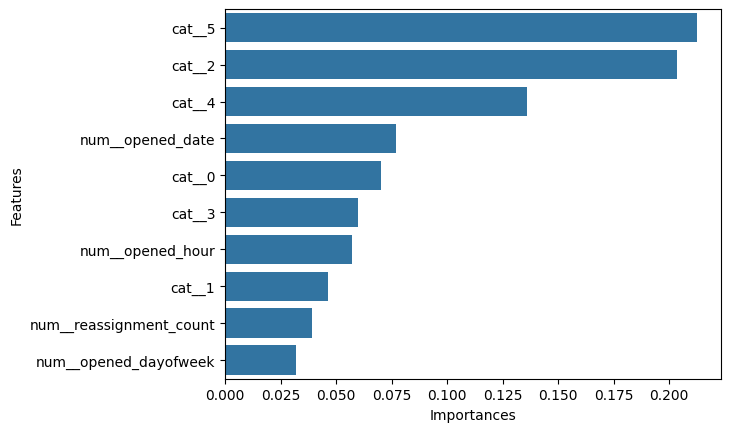

In [85]:
sns.barplot(top_10_features,y='Features',x='Importances')

## Train vs Test Performance Evaluation

Model performance was evaluated on both training and test datasets to assess overfitting.


In [86]:
print('Model Performance for Train Data',rf_pipeline.score(x_train, y_train))
print('Model Performance for Test Data',rf_pipeline.score(x_test, y_test))

Model Performance for Train Data 0.9622034302086345
Model Performance for Test Data 0.8133443239815632


- **Training R²:** ~0.96  
- **Test R²:** ~0.81  

The higher training score indicates slight overfitting, which is expected for ensemble models.  
However, the relatively strong test performance suggests good generalization capability.

## Cross-Validation Confirmation

To ensure the model’s stability across different data splits, 5-fold cross-validation with shuffling was performed.



In [87]:
from sklearn.model_selection import KFold,cross_val_score
kf=KFold(n_splits=5,shuffle=True,random_state=45)
cv_score=cross_val_score(rf_pipeline,x,y,cv=kf,scoring='r2')

In [88]:
np.mean(cv_score)

np.float64(0.787794878451828)

- **Mean Cross-Validation R²:** ~0.78

The close alignment between cross-validation score and test score (~0.81) confirms strong generalization capability and minimal dependence on a single train-test split.

## Creating Dataset Copy for Deep Learning Experiments

A copy of the dataset was created to perform deep learning experiments independently from the traditional machine learning pipeline.

This ensures separation between:

- Tree-based model experiments
- Neural network embedding experiments

In [89]:
df_dl=df.copy()

In [90]:
df_dl.columns

Index(['active', 'reassignment_count', 'location', 'category', 'subcategory',
       'u_symptom', 'impact', 'urgency', 'priority', 'assignment_group',
       'assigned_to', 'knowledge', 'u_priority_confirmation', 'opened_date',
       'opened_month', 'opened_dayofweek', 'opened_hour', 'closure_hours'],
      dtype='object')

In [91]:
df_dl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81608 entries, 0 to 81607
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   active                   81608 non-null  int64  
 1   reassignment_count       81608 non-null  int64  
 2   location                 81608 non-null  object 
 3   category                 81608 non-null  object 
 4   subcategory              81608 non-null  object 
 5   u_symptom                81608 non-null  object 
 6   impact                   81608 non-null  int64  
 7   urgency                  81608 non-null  int64  
 8   priority                 81608 non-null  int64  
 9   assignment_group         81608 non-null  object 
 10  assigned_to              81608 non-null  object 
 11  knowledge                81608 non-null  int64  
 12  u_priority_confirmation  81608 non-null  int64  
 13  opened_date              81608 non-null  int32  
 14  opened_month          

## Label Encoding for Embedding Layer Preparation

Categorical features intended for neural network embedding were converted into integer representations using `LabelEncoder`.

Embedding layers in deep learning models require numerical indices rather than string categories.

Each categorical column was encoded independently to map unique categories to integer indices.

In [92]:
from sklearn.preprocessing import LabelEncoder

cat_cols_for_embedding = df_dl.select_dtypes(include='object').columns

encoded_cat_inputs = []
for col in cat_cols_for_embedding:
    le = LabelEncoder()
    df_dl[col + '_encoded'] = le.fit_transform(df_dl[col])
    encoded_cat_inputs.append(col + '_encoded')

cat_col = encoded_cat_inputs

## Numerical Feature Selection for Neural Network

Numerical features were selected separately for the neural network model.


In [93]:
numeric_col=list(df_dl.select_dtypes(include='number').columns)
numeric_col.remove('closure_hours')

In [94]:
x=df_dl.drop('closure_hours',axis=1)
y=df_dl['closure_hours']

## Train–Test Split

The dataset was divided into training and testing sets using a 75/25 split.



In [95]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=45)


- **75% Training Data:** Used to train the neural network.
- **25% Testing Data:** Used to evaluate generalization performance.

A fixed `random_state` was set to ensure reproducibility of results.

## Input Preparation for Neural Network

Categorical and numerical features were prepared separately for the neural network architecture.

- **Categorical Features:** Extracted from the training and testing datasets to be passed into embedding layers.
- **Numerical Features:** Standardized using `StandardScaler` to ensure consistent scale and stable gradient-based optimization.

The scaler was fit only on the training data and applied to the test data to prevent data leakage.

In [96]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_num=sc.fit_transform(x[numeric_col])
x_train_num=sc.fit_transform(x_train[numeric_col])
x_test_num=sc.transform(x_test[numeric_col])

In [97]:
x_train_cat=x_train[cat_col]
x_test_cat=x_test[cat_col]

## Deep Learning Model with Embeddings

A neural network architecture was designed using Keras Functional API to handle both categorical and numerical features.

### Model Design:
- Individual input layers for each categorical feature
- Embedding layers to learn dense vector representations
- Flattened embedding outputs
- Concatenation with scaled numerical features
- Two fully connected hidden layers (ReLU activation)
- Single linear output neuron for regression

This architecture allows the model to learn nonlinear feature interactions and categorical relationships efficiently.

In [98]:
import tensorflow as tf

In [99]:
from tensorflow.keras.layers import Input,Dense,Embedding,Concatenate,Flatten
from tensorflow.keras.models import Model

In [100]:
input_list=[]
emb_list=[]
for col in cat_col:
  vocab_size=df_dl[col].nunique()
  input_layer=Input(shape=(1,),name=f'{col}_input')
  emb_layer=Embedding(input_dim=vocab_size,output_dim=min(50,(vocab_size)//2))(input_layer)
  emb_layer=Flatten(name=f'{col}_flatten')(emb_layer)
  input_list.append(input_layer)
  emb_list.append(emb_layer)

In [101]:
x_num.shape[1]

17

In [102]:
num_input=Input(shape=(x_num.shape[1],),name='numeric_input')

In [103]:
combined=Concatenate()(emb_list+[num_input])

In [104]:
hidden_layer=Dense(32,activation='relu')(combined)

In [105]:
hidden_layer=Dense(16,activation='relu')(hidden_layer)

In [106]:
output=Dense(1)(hidden_layer)

In [107]:
ann_model=Model(inputs=input_list+[num_input],outputs=output)

In [108]:
ann_model.compile(loss='mse',metrics=['mae'],optimizer='adam')

In [109]:
ann_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ location_encoded_i… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_encoded_i… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subcategory_encode… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ u_symptom_encoded_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assignment_group_e… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assigned_to_encode… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     10,150 │ location_encoded… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 22)     │        990 │ category_encoded… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 50)     │     11,050 │ subcategory_enco… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 50)     │     25,000 │ u_symptom_encode… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 36)     │      2,628 │ assignment_group… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 50)     │     10,450 │ assigned_to_enco… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location_encoded_f… │ (None, 50)        │          0 │ embedding[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_encoded_f… │ (None, 22)        │          0 │ embedding_1[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subcategory_encode… │ (None, 50)        │          0 │ embedding_2[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ u_symptom_encoded_… │ (None, 50)        │          0 │ embedding_3[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assignment_group_e… │ (None, 36)        │          0 │ embedding_4[0][0

 Total params: 69,645 (272.05 KB)

 Trainable params: 69,645 (272.05 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
x_train_fit=[x_train[col].values for col in cat_col]+[x_train_num]

## Model Training

The neural network was trained with:

- Loss Function: Mean Squared Error (MSE)
- Optimizer: Adam
- Evaluation Metric: Mean Absolute Error (MAE)
- Batch Size: 256
- Epochs: 10

Numerical inputs were standardized prior to training to ensure stable gradient updates.
Categorical features were converted to integer indices and passed through embedding layers.

In [1]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor='mae',patience=3,restore_best_weights=True)

In [118]:
ann_model.fit(x_train_fit,y_train,batch_size=256,verbose=2,epochs=10,callbacks=[early_stopping])

Epoch 1/10
240/240 - 3s - 14ms/step - loss: 192092.6562 - mae: 196.5772
Epoch 2/10
240/240 - 2s - 8ms/step - loss: 187823.6875 - mae: 193.8423
Epoch 3/10
240/240 - 2s - 10ms/step - loss: 184411.0625 - mae: 192.0258
Epoch 4/10
240/240 - 2s - 7ms/step - loss: 181170.7656 - mae: 190.9570
Epoch 5/10
240/240 - 3s - 11ms/step - loss: 178654.7344 - mae: 189.5327
Epoch 6/10
240/240 - 3s - 13ms/step - loss: 176089.0781 - mae: 187.8842
Epoch 7/10
240/240 - 3s - 11ms/step - loss: 174002.2031 - mae: 187.0394
Epoch 8/10
240/240 - 1s - 5ms/step - loss: 171930.3281 - mae: 185.9727
Epoch 9/10
240/240 - 1s - 4ms/step - loss: 170197.2812 - mae: 184.9950
Epoch 10/10
240/240 - 1s - 4ms/step - loss: 168325.2031 - mae: 183.8851


In [119]:
x_test_fit=[x_test[col].values.reshape(-1,1) for col in cat_col]+[x_test_num]

## Neural Network Performance


In [120]:
y_pred_ann_model=ann_model.predict(x_test_fit)

638/638 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [121]:
from sklearn.metrics import r2_score
r2_ann=r2_score(y_test,y_pred_ann_model)
print(r2_ann)

0.5696625565743765


- Test R² Score: ~0.569


While the neural network was able to capture nonlinear patterns, its predictive performance was lower compared to ensemble tree-based methods.

## Key Learning from Deep Learning Experiment

Although embeddings were used to represent categorical features, the neural network did not outperform the Random Forest model.

This demonstrates an important modeling insight:

Choosing the right model for the dataset structure is more important than using more complex architectures.

Empirical validation and performance comparison were critical in selecting the final production-ready model.

## Final Conclusion

After evaluating multiple modeling approaches:

- Random Forest achieved the best balance between accuracy and generalization.
- Cross-validation confirmed model robustness.
- Deep Learning experiments validated that ensemble methods are better suited for this structured dataset.

The final selected model is Random Forest Regressor due to its superior predictive performance and stability.